# Customer Support Ticket Classification and Response Retrieval

This notebook focuses on building machine learning models for customer support ticket classification and priority prediction. It also implements a response retrieval system that returns the most relevant response for a given customer query.

The workflow includes:
- Loading the processed dataset
- Category Classification
- Priority Prediction
- Response Retrieval using Cosine Similarity

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("/content/Bitext_Sample_Customer_Support_Dataset_with_priority.csv")
raw_df = pd.read_csv("/content/Bitext_Sample_Customer_Support_Training_Dataset_cleaned.csv")

In [3]:
df.head()

,instruction,response,category,intent,priority
0,"['question', 'cancel', 'order', 'order', 'numb...","[""i've"", 'understand', 'question', 'regard', '...",ORDER,cancel_order,High
1,"['question', 'cancel', 'order', 'order', 'numb...","[""i've"", 'inform', 'question', 'cancel', 'orde...",ORDER,cancel_order,High
2,"['need', 'help', 'cancel', 'purchase', 'order'...","['sense', 'are', 'seek', 'assistance', 'cancel...",ORDER,cancel_order,High
3,"['need', 'cancel', 'purchase', 'order', 'number']","['understand', 'need', 'assistance', 'cancel',...",ORDER,cancel_order,High
4,"['afford', 'order', 'cancel', 'purchase', 'ord...","['am', 'sensitive', 'fact', 'are', 'face', 'fi...",ORDER,cancel_order,High


In [4]:
df.shape

(26872, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   instruction  26872 non-null  object
 1   response     26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   priority     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [6]:
df.isnull().sum()

,0
instruction,0
response,0
category,0
intent,0
priority,0


In [7]:
df["category"].value_counts()

,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970


In [8]:
df["priority"].value_counts()

,count
priority,
Medium,10941
Low,7989
High,7942


# Intent Classification

"In this project, ticket classification is performed at the intent level because the intent provides a more specific representation of the customer's request than the broader category. This also aligns with the priority prediction and response retrieval modules."

The text data is converted into numerical feature vectors using **TF-IDF (Term Frequency-Inverse Document Frequency)**. Multiple machine learning models are trained and evaluated to identify the best-performing classifier for ticket categorization.

In [9]:
# Features and Target

X = df["instruction"]
y = df["intent"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## TF-IDF Vectorization

Machine learning algorithms cannot process raw text directly. Therefore, the customer queries are transformed into numerical feature vectors using the TF-IDF vectorization technique. TF-IDF assigns higher importance to words that are frequent within a document but less common across the entire dataset, making it an effective representation for text classification tasks.

In [11]:
intent_vectorizer = TfidfVectorizer(max_features=5000)

X_train_intent = intent_vectorizer.fit_transform(X_train)
X_test_intent = intent_vectorizer.transform(X_test)

## Model Training

In this section, multiple machine learning models are trained to classify customer support tickets into their respective categories. The performance of each model is evaluated using accuracy, classification report, and confusion matrix to identify the most suitable classifier.

##**Multinomial Naive Bayes Model**

In [12]:
# Training

nb_model = MultinomialNB()

nb_model.fit(X_train_intent, y_train)

MultinomialNB()

In [13]:
y_pred_nb = nb_model.predict(X_test_intent)

In [14]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Naive Bayes Accuracy: 0.9892


In [15]:
print(classification_report(y_test, y_pred_nb))

                          precision    recall  f1-score   support

            cancel_order       0.95      0.99      0.97       200
            change_order       0.96      0.97      0.96       199
 change_shipping_address       0.99      0.99      0.99       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.98      0.99      0.99       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       0.96      1.00      0.98       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      1.00      1.00       200
     contact_human_agent       1.00      0.99      1.00       200
          create_account       0.99      0.99      0.99       199
          delete_account       0.99      1.00      1.00       199
        delivery_options       0.99      1.00      0.99       199
         delivery_period       1.00      1.00      1.00       200
         

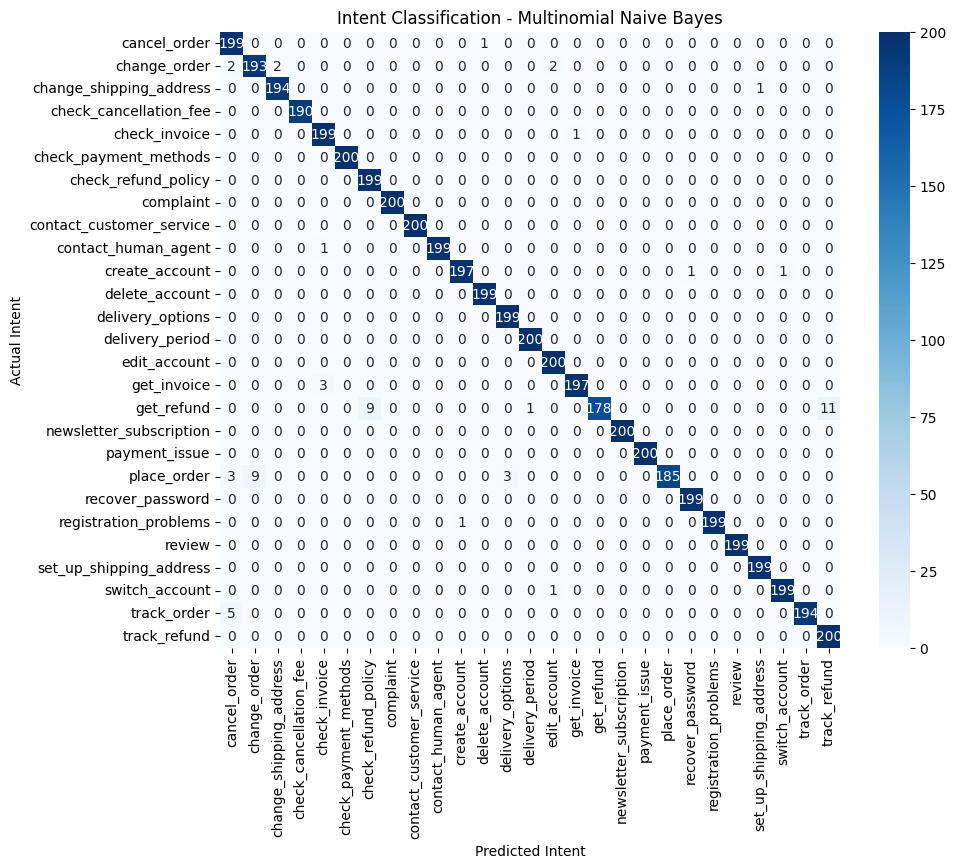

In [16]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.title("Intent Classification - Multinomial Naive Bayes")

plt.show()

##**Logistic Regression**

In [17]:
# Training

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_intent, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
y_pred_lr = lr_model.predict(X_test_intent)

In [19]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.9948


In [20]:
print(classification_report(y_test, y_pred_lr))

                          precision    recall  f1-score   support

            cancel_order       1.00      0.99      0.99       200
            change_order       0.97      0.98      0.97       199
 change_shipping_address       1.00      0.99      1.00       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.99      0.99      0.99       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.99      0.99       200
     contact_human_agent       1.00      1.00      1.00       200
          create_account       0.99      0.99      0.99       199
          delete_account       0.98      1.00      0.99       199
        delivery_options       1.00      1.00      1.00       199
         delivery_period       1.00      1.00      1.00       200
         

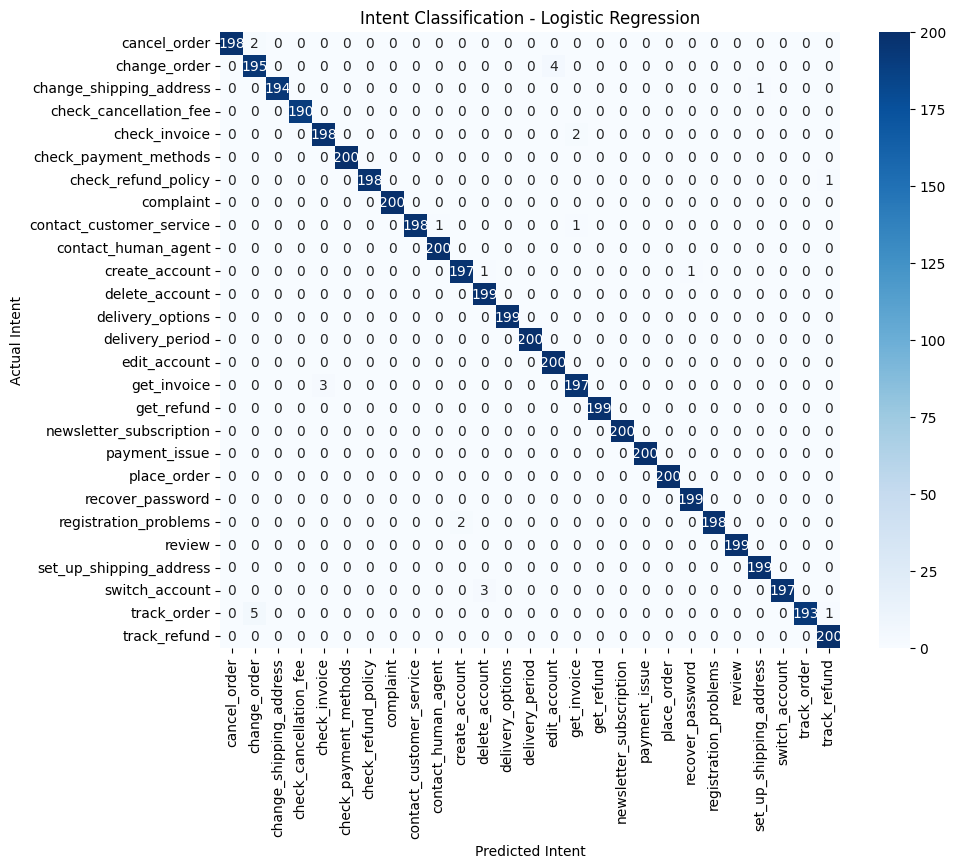

In [21]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.title("Intent Classification - Logistic Regression")

plt.show()

## Linear Support Vector Machine (Linear SVM)

Linear Support Vector Machine (Linear SVM) is a supervised learning algorithm widely used for text classification. It is particularly effective for high-dimensional sparse data, such as TF-IDF vectors, because it finds the optimal decision boundary that best separates different intent classes.

In [22]:
# Train Linear SVM Model

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_intent, y_train)

LinearSVC(random_state=42)

In [23]:
# Predict on Test Data

y_pred_svm = svm_model.predict(X_test_intent)

In [24]:
# Calculate Accuracy

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"Linear SVM Accuracy: {svm_accuracy:.4f}")

Linear SVM Accuracy: 0.9959


In [25]:
print(classification_report(y_test, y_pred_svm))

                          precision    recall  f1-score   support

            cancel_order       1.00      0.99      1.00       200
            change_order       0.97      0.98      0.97       199
 change_shipping_address       1.00      1.00      1.00       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.99      0.98      0.99       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      1.00      1.00       200
     contact_human_agent       1.00      0.99      1.00       200
          create_account       0.98      0.99      0.99       199
          delete_account       1.00      1.00      1.00       199
        delivery_options       1.00      1.00      1.00       199
         delivery_period       1.00      1.00      1.00       200
         

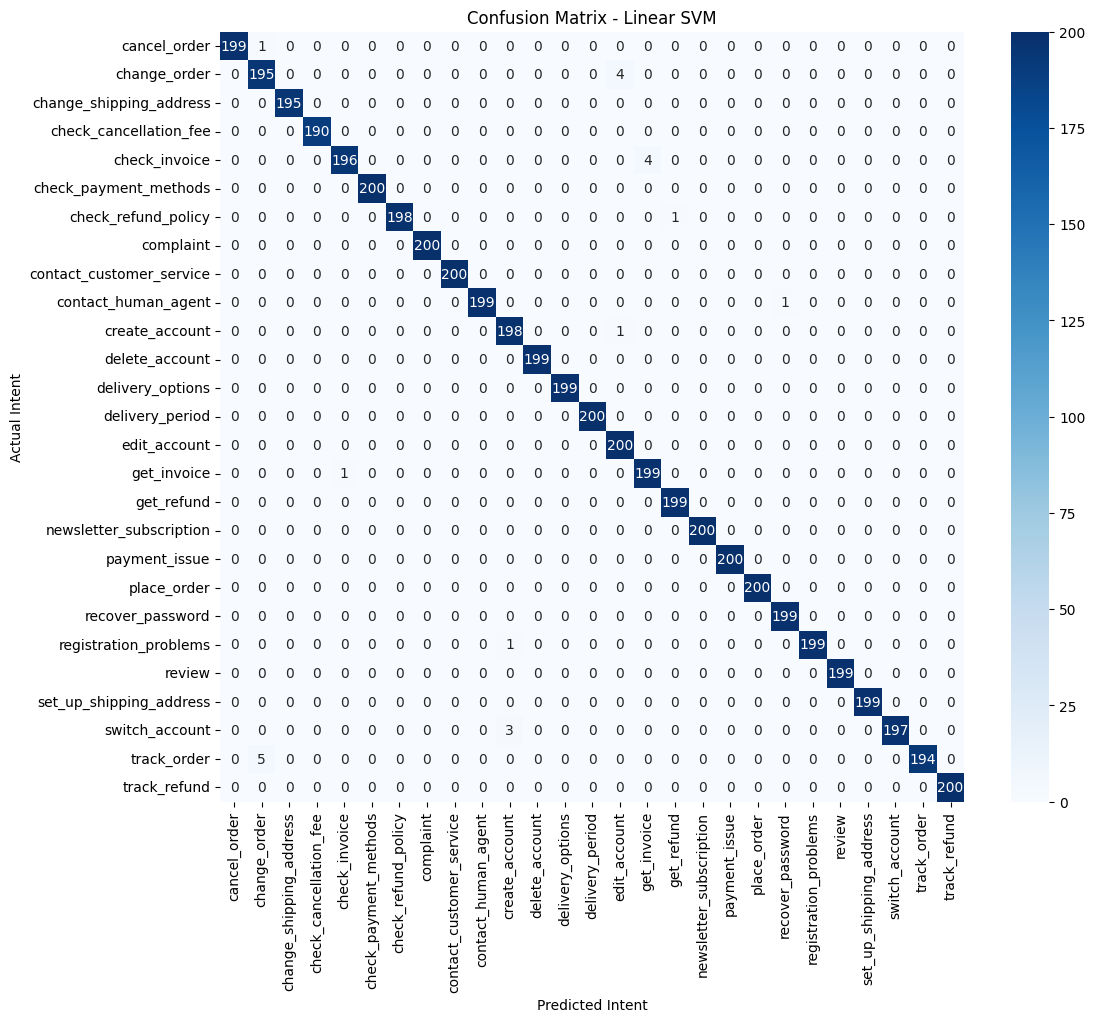

In [26]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ]
})

comparison["Accuracy (%)"] = (comparison["Accuracy"] * 100).round(2)

comparison

,Model,Accuracy,Accuracy (%)
0,Multinomial Naive Bayes,0.989209,98.92
1,Logistic Regression,0.994791,99.48
2,Linear SVM,0.995907,99.59


## Model Comparison and Selection

Three machine learning models were trained and evaluated for intent classification: Multinomial Naive Bayes, Logistic Regression, and Linear SVM.

The evaluation results show that **MULTINOMIAL NAIVE BAYES** achieved the highest classification accuracy. Therefore, it is selected as the final model for intent classification and will be used in the subsequent stages of the project.

# Priority Prediction

The objective of this module is to predict the priority level of customer support tickets based on the customer's query (`instruction`). The target variable is the `priority` column, which was generated using rule-based business logic based on the customer's intent.

The text data is transformed into numerical feature vectors using TF-IDF vectorization. Three machine learning models—Multinomial Naive Bayes, Logistic Regression, and Linear SVM—are trained and evaluated to identify the best-performing model for priority prediction.

In [28]:
# Features and Target

X = df["instruction"]
y = df["priority"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (21497,)
Testing Set : (5375,)


## TF-IDF Vectorization

The customer queries are transformed into TF-IDF feature vectors before training the classification models. TF-IDF assigns higher importance to words that are significant within a query while reducing the influence of commonly occurring words. This representation is particularly effective for text classification tasks.

In [31]:
# TF-IDF Vectorization for Priority Prediction

priority_vectorizer = TfidfVectorizer(max_features=5000)

X_train_priority = priority_vectorizer.fit_transform(X_train)
X_test_priority = priority_vectorizer.transform(X_test)

In [33]:
print("Training Matrix:", X_train_intent.shape)
print("Testing Matrix :", X_test_intent.shape)

Training Matrix: (21497, 843)
Testing Matrix : (5375, 843)


#**Multinomial Naive Bayes**

In [34]:
# Training

nb_priority_model = MultinomialNB()

nb_priority_model.fit(X_train_priority, y_train)

MultinomialNB()

In [35]:
# Predict on Test Data

y_pred_nb_priority = nb_priority_model.predict(X_test_priority)

In [36]:
# Calculate Accuracy

nb_priority_accuracy = accuracy_score(y_test, y_pred_nb_priority)

print(f"Multinomial Naive Bayes Accuracy: {nb_priority_accuracy:.4f}")

Multinomial Naive Bayes Accuracy: 0.9868


In [37]:
print(classification_report(y_test, y_pred_nb_priority))

              precision    recall  f1-score   support

        High       0.98      0.98      0.98      1589
         Low       0.99      0.99      0.99      1598
      Medium       0.98      0.99      0.98      2188

    accuracy                           0.99      5375
   macro avg       0.99      0.99      0.99      5375
weighted avg       0.99      0.99      0.99      5375



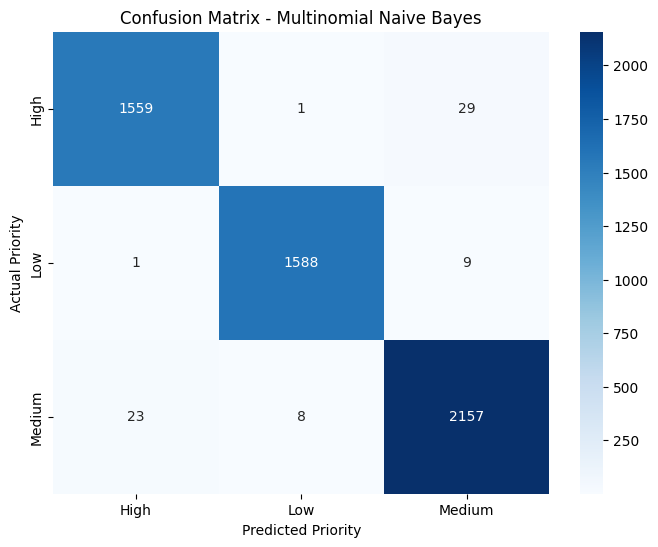

In [38]:
cm = confusion_matrix(y_test, y_pred_nb_priority)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nb_priority_model.classes_,
    yticklabels=nb_priority_model.classes_
)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.show()

#**LOGISTIC REGRESSION**

In [39]:
# Training

lr_priority_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_priority_model.fit(X_train_priority, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [40]:
# Predict on Test Data

y_pred_lr_priority = lr_priority_model.predict(X_test_priority)

In [41]:
# Calculate Accuracy

lr_priority_accuracy = accuracy_score(y_test, y_pred_lr_priority)

print(f"Logistic Regression Accuracy: {lr_priority_accuracy:.4f}")

Logistic Regression Accuracy: 0.9974


In [42]:
print(classification_report(y_test, y_pred_lr_priority))

              precision    recall  f1-score   support

        High       1.00      0.99      1.00      1589
         Low       1.00      1.00      1.00      1598
      Medium       1.00      1.00      1.00      2188

    accuracy                           1.00      5375
   macro avg       1.00      1.00      1.00      5375
weighted avg       1.00      1.00      1.00      5375



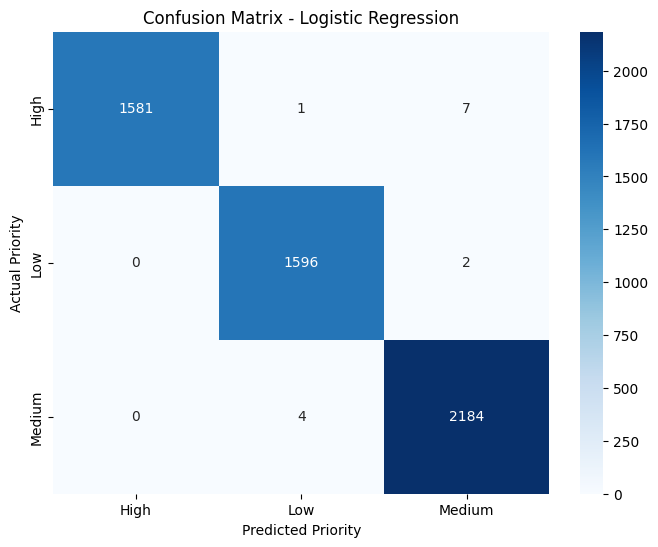

In [43]:
cm = confusion_matrix(y_test, y_pred_lr_priority)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_priority_model.classes_,
    yticklabels=lr_priority_model.classes_
)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

#**LINEAR SVM**




In [44]:
# Train Linear SVM Model

svm_priority_model = LinearSVC(random_state=42)

svm_priority_model.fit(X_train_priority, y_train)

LinearSVC(random_state=42)

In [45]:
# Predict on Test Data

y_pred_svm_priority = svm_priority_model.predict(X_test_priority)

In [46]:
# Calculate Accuracy

svm_priority_accuracy = accuracy_score(y_test, y_pred_svm_priority)

print(f"Linear SVM Accuracy: {svm_priority_accuracy:.4f}")

Linear SVM Accuracy: 0.9980


In [47]:
print(classification_report(y_test, y_pred_svm_priority))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1589
         Low       1.00      1.00      1.00      1598
      Medium       1.00      1.00      1.00      2188

    accuracy                           1.00      5375
   macro avg       1.00      1.00      1.00      5375
weighted avg       1.00      1.00      1.00      5375



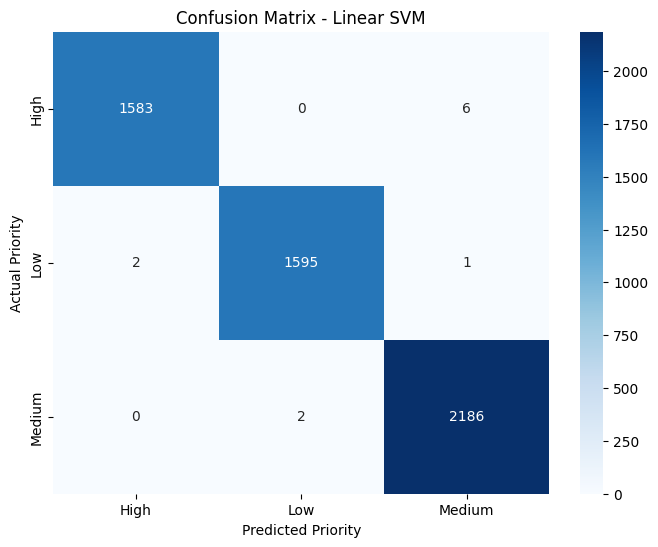

In [48]:
cm = confusion_matrix(y_test, y_pred_svm_priority)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_priority_model.classes_,
    yticklabels=svm_priority_model.classes_
)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_priority_accuracy,
        lr_priority_accuracy,
        svm_priority_accuracy
    ]
})

comparison["Accuracy (%)"] = (comparison["Accuracy"] * 100).round(2)

comparison

,Model,Accuracy,Accuracy (%)
0,Multinomial Naive Bayes,0.986791,98.68
1,Logistic Regression,0.997395,99.74
2,Linear SVM,0.997953,99.80


In [50]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model for Priority Prediction")
print(best_model)

Best Model for Priority Prediction
Model           Linear SVM
Accuracy          0.997953
Accuracy (%)          99.8
Name: 2, dtype: object


## Model Comparison and Selection

Three machine learning models—Multinomial Naive Bayes, Logistic Regression, and Linear SVM—were trained and evaluated for priority prediction.

Based on the evaluation metrics, **LINEAR SVM** achieved the highest classification accuracy and was selected as the final model for predicting the priority level of customer support tickets.

# Response Retrieval

The objective of this module is to retrieve the most relevant response for a customer query. The system first predicts the customer's intent and priority using the trained machine learning models. It then compares the query with all existing customer queries in the dataset using TF-IDF vectorization and Cosine Similarity to retrieve the most appropriate response.

In [51]:
# TF-IDF Vectorizer for Response Retrieval

retrieval_vectorizer = TfidfVectorizer()

instruction_vectors = retrieval_vectorizer.fit_transform(df["instruction"])

In [58]:
def retrieve_response(user_query):

    query_vector = retrieval_vectorizer.transform([user_query])

    similarity_scores = cosine_similarity(query_vector, instruction_vectors)

    best_match = similarity_scores.argmax()

    # Return the original response from the raw dataset
    return raw_df.iloc[best_match]["response"]

In [59]:
def customer_support_system(user_query):

    # ---------- Intent Prediction ----------
    intent_query = intent_vectorizer.transform([user_query])
    predicted_intent = svm_model.predict(intent_query)[0]

    # ---------- Priority Prediction ----------
    priority_query = priority_vectorizer.transform([user_query])
    predicted_priority = svm_priority_model.predict(priority_query)[0]

    # ---------- Response Retrieval ----------
    response = retrieve_response(user_query)

    print("=" * 60)
    print("Customer Query:")
    print(user_query)

    print("\nPredicted Intent:")
    print(predicted_intent)

    print("\nPredicted Priority:")
    print(predicted_priority)

    print("\nRetrieved Response:")
    print(response)

In [60]:
customer_support_system("I forgot my password")

Customer Query:
I forgot my password

Predicted Intent:
recover_password

Predicted Priority:
Medium

Retrieved Response:
Of course! I understand that you need assistance in restoring the password of your user profile. Rest assured, I'm here to guide you through the process step by step.

To restore your password, please follow these simple instructions:

1. Visit the "{{Login Page URL}}" of our platform.
2. Look for the option that says "{{Forgot Password}}" and click on it.
3. Enter the email address associated with your user profile in the designated field.
4. Within a short period, you should receive an email with comprehensive instructions for resetting your password. Don't forget to check your spam or junk folder in case it gets filtered there.
5. Carefully follow the instructions outlined in the email to create a new, secure password for your user profile.

If you encounter any difficulties or if the email doesn't arrive in a timely manner, please don't hesitate to reach out to 